In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('/content/drive/MyDrive/netflix_cleaned.csv')
df.shape

(8797, 12)

In [3]:
df['date_added'] = pd.to_datetime(df['date_added'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8797 entries, 0 to 8796
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8797 non-null   object        
 1   type          8797 non-null   object        
 2   title         8797 non-null   object        
 3   director      8797 non-null   object        
 4   cast          8797 non-null   object        
 5   country       8797 non-null   object        
 6   date_added    8797 non-null   datetime64[ns]
 7   release_year  8797 non-null   int64         
 8   rating        8797 non-null   object        
 9   duration      8797 non-null   object        
 10  listed_in     8797 non-null   object        
 11  description   8797 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 824.8+ KB


In [4]:
df.describe()

,date_added,release_year
count,8797,8797.000000
mean,2019-05-17 05:59:08.436966912,2014.183472
min,2008-01-01 00:00:00,1925.000000
25%,2018-04-06 00:00:00,2013.000000
50%,2019-07-02 00:00:00,2017.000000
75%,2020-08-19 00:00:00,2019.000000
max,2021-09-25 00:00:00,2021.000000
std,NaN,8.822191


type
Movie      6131
TV Show    2666
Name: count, dtype: int64


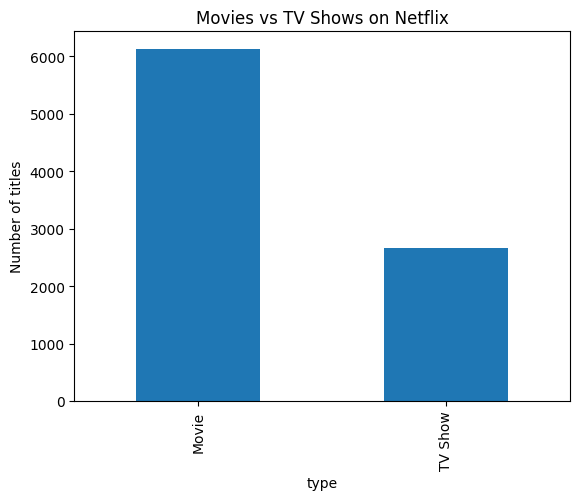

In [5]:
counts = df['type'].value_counts()
print(counts)
counts.plot(kind='bar', title='Movies vs TV Shows on Netflix')
plt.ylabel('Number of titles')
plt.show()

In [6]:
counts['Movie'] / counts.sum() * 100

np.float64(69.69421393656928)

In [7]:
round(counts['Movie'] / counts.sum() * 100, 1)

np.float64(69.7)

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1188
2018    1649
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64


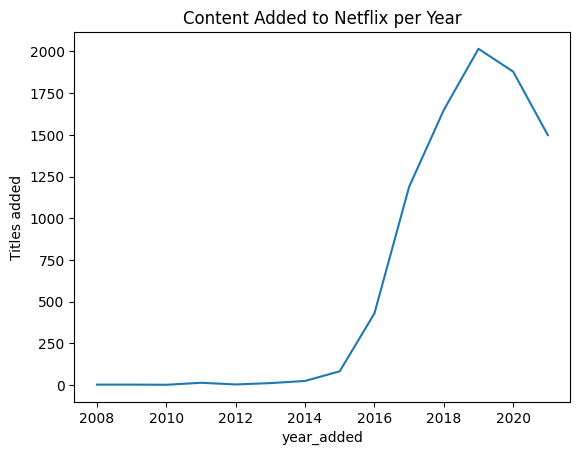

In [8]:
df['year_added'] = df['date_added'].dt.year
per_year = df['year_added'].value_counts().sort_index()
print(per_year)
per_year.plot(kind='line', title='Content Added to Netflix per Year')
plt.ylabel('Titles added')
plt.show()

country
United States     2812
India              972
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64


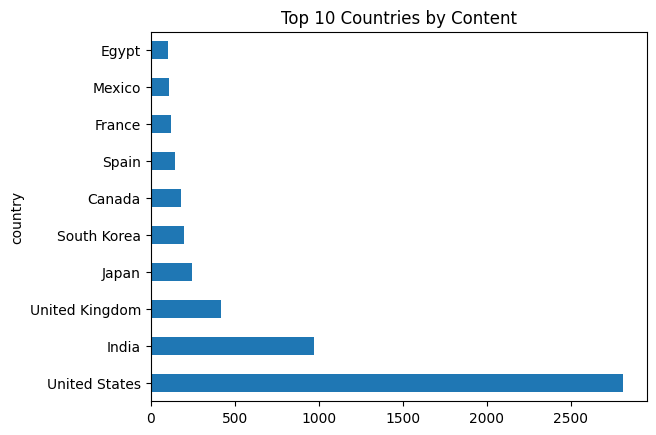

In [9]:
top_countries = df[df['country'] != 'Unknown']['country'].value_counts().head(10)
print(top_countries)
top_countries.plot(kind='barh', title='Top 10 Countries by Content')
plt.show()

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1350
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


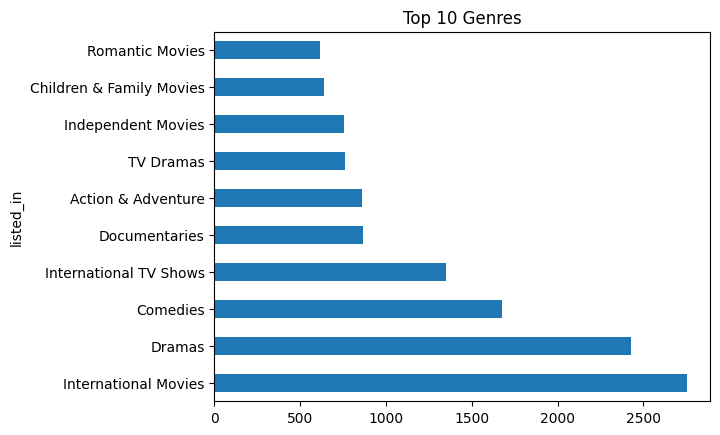

In [10]:
genres = df['listed_in'].str.split(', ').explode().value_counts().head(10)
print(genres)
genres.plot(kind='barh', title='Top 10 Genres')
plt.show()

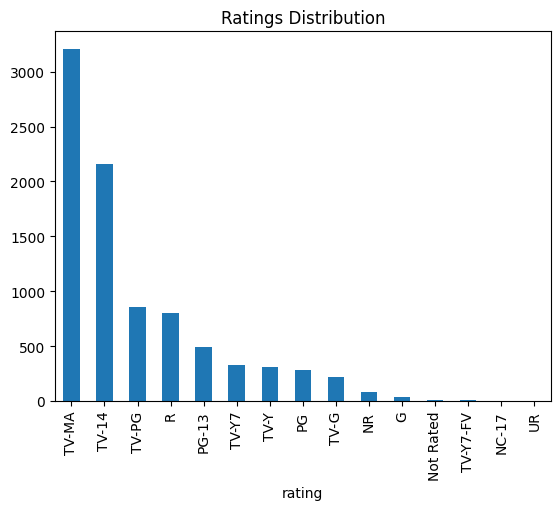

In [11]:
df['rating'].value_counts().plot(kind='bar', title='Ratings Distribution')
plt.show()

In [12]:
movies = df[df['type'] == 'Movie'].copy()
movies['minutes'] = movies['duration'].str.replace(' min', '').astype(int)
movies['minutes'].describe()

,minutes
count,6131.000000
mean,99.564998
std,28.289504
min,3.000000
25%,87.000000
50%,98.000000
75%,114.000000
max,312.000000


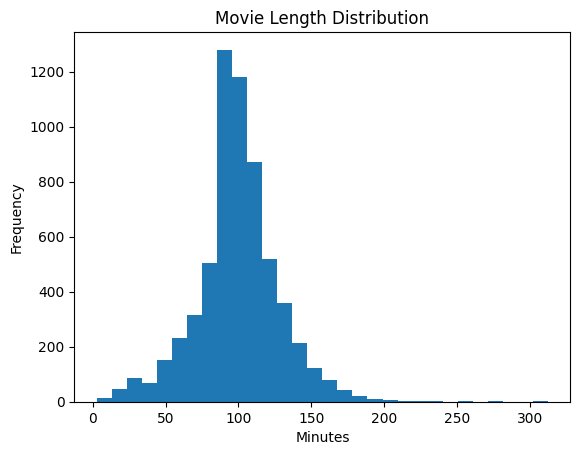

In [13]:
movies['minutes'].plot(kind='hist', bins=30, title='Movie Length Distribution')
plt.xlabel('Minutes')
plt.show()

In [14]:
movies.sort_values('minutes').head(5)[['title', 'minutes', 'release_year']]
movies.sort_values('minutes').tail(5)[['title', 'minutes', 'release_year']]

,title,minutes,release_year
2484,Lock Your Girls In,233,1982
2487,No Longer kids,237,1979
2491,The School of Mischief,253,1973
717,Headspace: Unwind Your Mind,273,2021
4253,Black Mirror: Bandersnatch,312,2018


In [15]:
df['gap_years'] = df['date_added'].dt.year - df['release_year']
df.sort_values('gap_years', ascending=False).head(5)[['title', 'release_year', 'year_added', 'gap_years']]

,title,release_year,year_added,gap_years
4250,Pioneers: First Women Filmmakers*,1925,2018,93
1331,Five Came Back: The Reference Films,1945,2021,76
8195,The Battle of Midway,1942,2017,75
7782,Prelude to War,1942,2017,75
8753,WWII: Report from the Aleutians,1943,2017,74


In [16]:
df['year_added'] = df['date_added'].dt.year
per_year = df['year_added'].value_counts().sort_index()
print(per_year)

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1188
2018    1649
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64


In [17]:
peak_year = per_year.idxmax()
peak_count = per_year.max()
print("Peak year:", peak_year)
print("Titles added that year:", peak_count)

Peak year: 2019
Titles added that year: 2016


In [18]:
row = df.sort_values('gap_years', ascending=False).iloc[0]
print("Title:", row['title'])
print("Released in:", row['release_year'])
print("Added to Netflix in:", row['year_added'])
print("Gap:", int(row['gap_years']), "years")

Title: Pioneers: First Women Filmmakers*
Released in: 1925
Added to Netflix in: 2018
Gap: 93 years


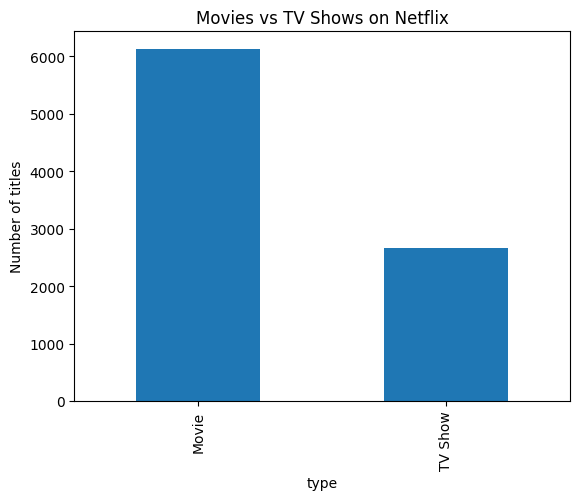

In [19]:
counts = df['type'].value_counts()
counts.plot(kind='bar', title='Movies vs TV Shows on Netflix')
plt.ylabel('Number of titles')
plt.savefig('/content/drive/MyDrive/chart1_type.png', bbox_inches='tight')
plt.show()

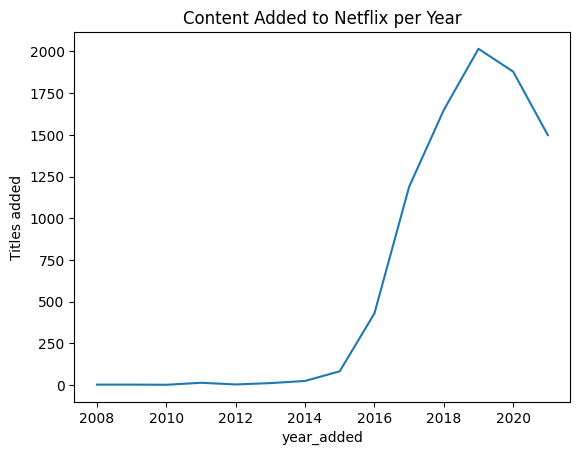

In [20]:
per_year.plot(kind='line', title='Content Added to Netflix per Year')
plt.ylabel('Titles added')
plt.savefig('/content/drive/MyDrive/chart2_year.png', bbox_inches='tight')
plt.show()

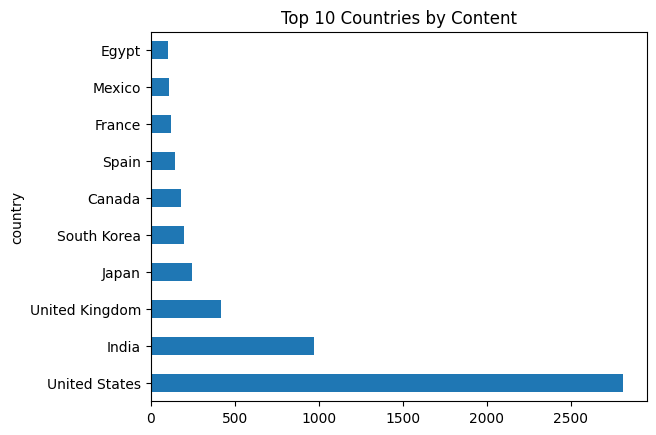

In [21]:
top_countries = df[df['country'] != 'Unknown']['country'].value_counts().head(10)
top_countries.plot(kind='barh', title='Top 10 Countries by Content')
plt.savefig('/content/drive/MyDrive/chart3_countries.png', bbox_inches='tight')
plt.show()

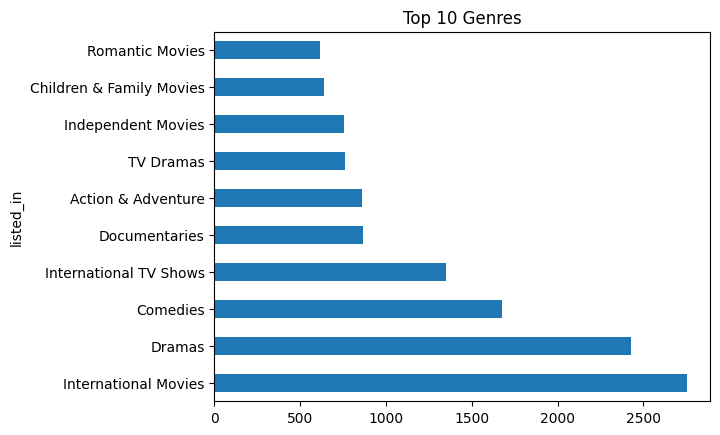

In [22]:
genres = df['listed_in'].str.split(', ').explode().value_counts().head(10)
genres.plot(kind='barh', title='Top 10 Genres')
plt.savefig('/content/drive/MyDrive/chart4_genres.png', bbox_inches='tight')
plt.show()

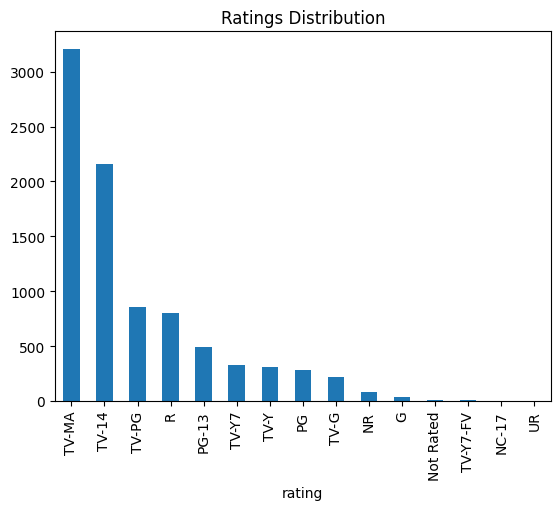

In [23]:
df['rating'].value_counts().plot(kind='bar', title='Ratings Distribution')
plt.savefig('/content/drive/MyDrive/chart5_ratings.png', bbox_inches='tight')
plt.show()

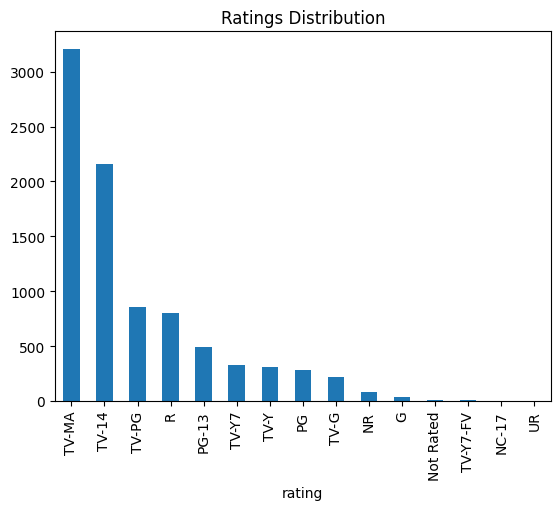

In [24]:
df['rating'].value_counts().plot(kind='bar', title='Ratings Distribution')
plt.savefig('/content/drive/MyDrive/chart5_ratings.png', bbox_inches='tight')
plt.show()